# OT/ICS Autoencoder — Rigorous Evaluation on the HAI Testbed

Reproduces the OT/ICS paper's evaluation: the leakage-free autoencoder is scored on the canonical HAI held-out test files (test1 + test2). Computes ROC AUC, average precision, a threshold-sensitivity sweep, per-process detection, point-wise and point-adjusted operating points, and PCA / Isolation-Forest baselines. Results and figures are written to `paper/ot_ics/` and shown inline.

**Prerequisites:** `data/raw/test1.csv`, `data/raw/test2.csv`, `data/raw/train1.csv`, `data/raw/train2.csv` (HAI dataset) and the trained model `data/processed/autoencoder_hai.pth` + `scaler_hai.pkl` + `autoencoder_hai_meta.txt`.

In [1]:
# --- notebook path shim (makes the embedded evaluation script runnable in Jupyter) ---
from pathlib import Path


def _repo_root(p):
    for a in [p, *p.parents]:
        if (a / "data" / "processed").exists():
            return a
    return p


REPO = _repo_root(Path.cwd())
(REPO / "paper" / "ot_ics").mkdir(parents=True, exist_ok=True)
(REPO / "paper" / "ot_ics" / "figures").mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)


Repo root: C:\Users\User\ai-cybersecurity-portfolio


In [2]:
"""
Rigorous, paper-aware evaluation of the leakage-free OT/ICS autoencoder detector
on the HAI testbed.

Produces (into paper/):
  - results_ot_ics.json        machine-readable metrics
  - figures/roc.png            ROC curve (AUC)
  - figures/pr.png             precision-recall curve (AP)
  - figures/error_hist.png     reconstruction-error distribution, normal vs attack
  - figures/threshold_sweep.png recall/precision/FPR vs threshold, operating point marked

Ground truth = the HAI `attack` column on the held-out test splits. Score =
per-sample reconstruction MSE. Threshold-free metrics (ROC/AUC, AP) characterize
the detector independent of any operating point; the operating threshold from the
model metadata is evaluated and situated on a sensitivity sweep. Baselines (PCA
reconstruction, Isolation Forest) are trained on the same normal data for a fair
comparison.
"""
import ast
import json
from pathlib import Path

import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

def _find_root(p):
    for a in [p, *p.parents]:
        if (a / "data" / "processed").exists():
            return a
    return p.parent


ROOT = REPO
DATA_RAW = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"
FIGS = REPO / "paper" / "ot_ics" / "figures"
FIGS.mkdir(exist_ok=True)
RESULTS = REPO / "paper" / "ot_ics" / "results_ot_ics.json"

NORMAL_SAMPLE = 100_000  # normal training rows sampled for threshold + baselines
SEED = 42
rng = np.random.default_rng(SEED)


# ---- model ---------------------------------------------------------------
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, encoding_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def load_meta():
    meta = {}
    for line in (DATA_PROC / "autoencoder_hai_meta.txt").read_text().splitlines():
        k, _, v = line.partition("=")
        meta[k] = v
    return meta


def read_features(path, feature_cols):
    """Return (X float32, attack, attack_P1, attack_P2, attack_P3) as numpy."""
    cols = feature_cols + ["attack", "attack_P1", "attack_P2", "attack_P3"]
    # Force numeric dtypes: some sensor columns look int in the first rows but
    # hold floats later, which breaks polars' schema inference.
    overrides = {c: pl.Float64 for c in feature_cols}
    df = pl.read_csv(path, separator=";", columns=cols, schema_overrides=overrides)
    X = df.select(feature_cols).to_numpy().astype(np.float32)
    y = df["attack"].to_numpy().astype(int)
    p1 = df["attack_P1"].to_numpy().astype(int)
    p2 = df["attack_P2"].to_numpy().astype(int)
    p3 = df["attack_P3"].to_numpy().astype(int)
    return X, y, p1, p2, p3


def ae_errors(model, Xs, batch=8192):
    """Per-sample reconstruction MSE for standardized input Xs."""
    errs = np.empty(len(Xs), dtype=np.float64)
    model.eval()
    with torch.no_grad():
        for i in range(0, len(Xs), batch):
            xb = torch.tensor(Xs[i:i + batch], dtype=torch.float32)
            rb = model(xb)
            errs[i:i + batch] = torch.mean((rb - xb) ** 2, dim=1).numpy()
    return errs


def _metrics_from_pred(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    acc = (tp + tn) / len(y)
    return dict(tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn),
               recall=recall, precision=precision, specificity=specificity,
               fpr=fpr, f1=f1, accuracy=acc)


def _point_adjust(y_seg, pred_seg):
    """ICS/time-series convention: if any point in a contiguous ground-truth
    anomaly segment is flagged, count the whole segment as detected."""
    pred = pred_seg.copy()
    i, n = 0, len(y_seg)
    while i < n:
        if y_seg[i] == 1:
            j = i
            while j < n and y_seg[j] == 1:
                j += 1
            if pred[i:j].any():
                pred[i:j] = 1
            i = j
        else:
            i += 1
    return pred


def op_metrics(y, scores, thr):
    pred = (scores > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    acc = (tp + tn) / len(y)
    return dict(tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn),
               recall=recall, precision=precision, specificity=specificity,
               fpr=fpr, f1=f1, accuracy=acc)


def main():
    meta = load_meta()
    feature_cols = ast.literal_eval(meta["feature_cols"])
    input_dim = int(meta["input_dim"])
    encoding_dim = int(meta["encoding_dim"])
    threshold = float(meta["threshold"])
    print(f"features={len(feature_cols)} input_dim={input_dim} threshold={threshold}")

    scaler = joblib.load(DATA_PROC / "scaler_hai.pkl")
    model = Autoencoder(input_dim, encoding_dim)
    model.load_state_dict(torch.load(DATA_PROC / "autoencoder_hai.pth", map_location="cpu"))

    # ---- test set (test1 + test2) ----
    Xt1, y1, p1a, p2a, p3a = read_features(DATA_RAW / "test1.csv", feature_cols)
    Xt2, y2, p1b, p2b, p3b = read_features(DATA_RAW / "test2.csv", feature_cols)
    Xtest = np.vstack([Xt1, Xt2])
    y = np.concatenate([y1, y2])
    p1 = np.concatenate([p1a, p1b]); p2 = np.concatenate([p2a, p2b]); p3 = np.concatenate([p3a, p3b])
    print(f"test rows={len(y)} attacks={int(y.sum())} ({100*y.mean():.2f}%)")

    Xtest_s = scaler.transform(Xtest).astype(np.float32)
    err = ae_errors(model, Xtest_s)

    # ---- threshold-free ----
    auc = roc_auc_score(y, err)
    ap = average_precision_score(y, err)
    fpr_c, tpr_c, _ = roc_curve(y, err)
    prec_c, rec_c, _ = precision_recall_curve(y, err)

    # ---- operating point (point-wise) ----
    op = op_metrics(y, err, threshold)

    # ---- point-adjusted operating point (per split, then combined) ----
    err1, err2 = err[:len(y1)], err[len(y1):]
    pa_pred = np.concatenate([
        _point_adjust(y1, (err1 > threshold).astype(int)),
        _point_adjust(y2, (err2 > threshold).astype(int)),
    ])
    op_pa = _metrics_from_pred(y, pa_pred)

    # ---- per-process detection (recall on each process's attack rows) ----
    def proc_recall(mask):
        m = mask == 1
        return float(((err > threshold) & m).sum() / m.sum()) if m.sum() else None
    per_process = {"P1": proc_recall(p1), "P2": proc_recall(p2), "P3": proc_recall(p3),
                   "P1_n": int((p1 == 1).sum()), "P2_n": int((p2 == 1).sum()), "P3_n": int((p3 == 1).sum())}

    # ---- normal-training errors: justify the threshold percentile + feed baselines ----
    tr_overrides = {c: pl.Float64 for c in feature_cols}
    tr = pl.concat([
        pl.read_csv(DATA_RAW / "train1.csv", separator=";", columns=feature_cols + ["attack"], schema_overrides=tr_overrides),
        pl.read_csv(DATA_RAW / "train2.csv", separator=";", columns=feature_cols + ["attack"], schema_overrides=tr_overrides),
    ])
    tr_norm = tr.filter(pl.col("attack") == 0).select(feature_cols).to_numpy().astype(np.float32)
    idx = rng.choice(len(tr_norm), size=min(NORMAL_SAMPLE, len(tr_norm)), replace=False)
    norm_sample = tr_norm[idx]
    norm_sample_s = scaler.transform(norm_sample).astype(np.float32)
    norm_err = ae_errors(model, norm_sample_s)
    # what percentile of normal errors does the chosen threshold correspond to?
    thr_percentile = float((norm_err <= threshold).mean() * 100)
    pct_thresholds = {p: float(np.percentile(norm_err, p)) for p in (90, 95, 97.5, 99, 99.9)}
    pct_metrics = {str(p): op_metrics(y, err, t) for p, t in pct_thresholds.items()}

    # ---- baselines on the same normal sample ----
    baselines = {}
    # PCA reconstruction (match encoding_dim)
    pca = PCA(n_components=encoding_dim, random_state=SEED).fit(norm_sample_s)
    pca_rec = pca.inverse_transform(pca.transform(Xtest_s))
    pca_err = np.mean((Xtest_s - pca_rec) ** 2, axis=1)
    baselines["pca"] = {"auc": float(roc_auc_score(y, pca_err)), "ap": float(average_precision_score(y, pca_err))}
    # Isolation Forest (higher score = more anomalous -> use -score_samples)
    iso = IsolationForest(n_estimators=100, random_state=SEED, n_jobs=-1).fit(norm_sample_s)
    iso_score = -iso.score_samples(Xtest_s)
    baselines["isolation_forest"] = {"auc": float(roc_auc_score(y, iso_score)), "ap": float(average_precision_score(y, iso_score))}

    # ---- figures ----
    plt.figure(figsize=(5, 4))
    plt.plot(fpr_c, tpr_c, label=f"Autoencoder (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=0.8)
    plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
    plt.title("OT/ICS detection — ROC"); plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(FIGS / "roc.png", dpi=200); plt.close()

    plt.figure(figsize=(5, 4))
    plt.plot(rec_c, prec_c, label=f"Autoencoder (AP={ap:.3f})")
    plt.axhline(y.mean(), color="k", ls="--", lw=0.8, label=f"chance ({y.mean():.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("OT/ICS detection — Precision-Recall"); plt.legend(loc="lower left"); plt.tight_layout()
    plt.savefig(FIGS / "pr.png", dpi=200); plt.close()

    plt.figure(figsize=(6, 4))
    bins = np.logspace(np.log10(max(err.min(), 1e-6)), np.log10(err.max()), 80)
    plt.hist(err[y == 0], bins=bins, alpha=0.6, label="normal", density=True)
    plt.hist(err[y == 1], bins=bins, alpha=0.6, label="attack", density=True)
    plt.axvline(threshold, color="r", ls="--", label=f"threshold={threshold:.4g}")
    plt.xscale("log"); plt.xlabel("reconstruction error (MSE, log)"); plt.ylabel("density")
    plt.title("Reconstruction error: normal vs attack"); plt.legend(); plt.tight_layout()
    plt.savefig(FIGS / "error_hist.png", dpi=200); plt.close()

    sweep_thr = np.percentile(norm_err, np.linspace(50, 99.99, 200))
    sw_rec, sw_prec, sw_fpr = [], [], []
    for t in sweep_thr:
        m = op_metrics(y, err, t)
        sw_rec.append(m["recall"]); sw_prec.append(m["precision"]); sw_fpr.append(m["fpr"])
    plt.figure(figsize=(6, 4))
    plt.plot(sweep_thr, sw_rec, label="recall")
    plt.plot(sweep_thr, sw_prec, label="precision")
    plt.plot(sweep_thr, sw_fpr, label="false-positive rate")
    plt.axvline(threshold, color="r", ls="--", label=f"operating pt ({thr_percentile:.1f}th pct)")
    plt.xscale("log"); plt.xlabel("threshold (MSE, log)"); plt.ylabel("rate")
    plt.title("Threshold sensitivity"); plt.legend(); plt.tight_layout()
    plt.savefig(FIGS / "threshold_sweep.png", dpi=200); plt.close()

    results = {
        "test": {"rows": int(len(y)), "attacks": int(y.sum()), "attack_pct": float(100 * y.mean()),
                 "test1_rows": int(len(y1)), "test1_attacks": int(y1.sum()),
                 "test2_rows": int(len(y2)), "test2_attacks": int(y2.sum())},
        "threshold": threshold,
        "threshold_normal_percentile": thr_percentile,
        "threshold_free": {"auc": float(auc), "average_precision": float(ap)},
        "operating_point": op,
        "operating_point_point_adjusted": op_pa,
        "per_process": per_process,
        "percentile_thresholds": pct_thresholds,
        "percentile_metrics": pct_metrics,
        "baselines": baselines,
        "config": {"normal_sample": int(len(norm_sample)), "seed": SEED},
    }
    RESULTS.write_text(json.dumps(results, indent=2))

    print("\n==== SUMMARY ====")
    print(f"AUC={auc:.4f}  AP={ap:.4f}")
    print(f"@threshold {threshold:.4g} ({thr_percentile:.1f}th pct of normal): "
          f"recall={op['recall']:.3f} precision={op['precision']:.3f} "
          f"specificity={op['specificity']:.3f} F1={op['f1']:.3f} FPR={op['fpr']:.4f}")
    print(f"  point-adjusted: recall={op_pa['recall']:.3f} precision={op_pa['precision']:.3f} "
          f"F1={op_pa['f1']:.3f} FPR={op_pa['fpr']:.4f}")
    print(f"per-process recall: P1={per_process['P1']:.3f} P2={per_process['P2']:.3f} P3={per_process['P3']:.3f}")
    print(f"baselines: PCA AUC={baselines['pca']['auc']:.3f}  IF AUC={baselines['isolation_forest']['auc']:.3f}")
    print(f"results -> {RESULTS}")
    print(f"figures -> {FIGS}")


main()


features=59 input_dim=59 threshold=0.009223


test rows=444600 attacks=17527 (3.94%)



==== SUMMARY ====
AUC=0.9290  AP=0.7331
@threshold 0.009223 (90.8th pct of normal): recall=0.879 precision=0.152 specificity=0.799 F1=0.259 FPR=0.2010
  point-adjusted: recall=1.000 precision=0.170 F1=0.290 FPR=0.2010
per-process recall: P1=0.883 P2=0.965 P3=0.853
baselines: PCA AUC=0.854  IF AUC=0.804
results -> C:\Users\User\ai-cybersecurity-portfolio\paper\ot_ics\results_ot_ics.json
figures -> C:\Users\User\ai-cybersecurity-portfolio\paper\ot_ics\figures


error_hist.png


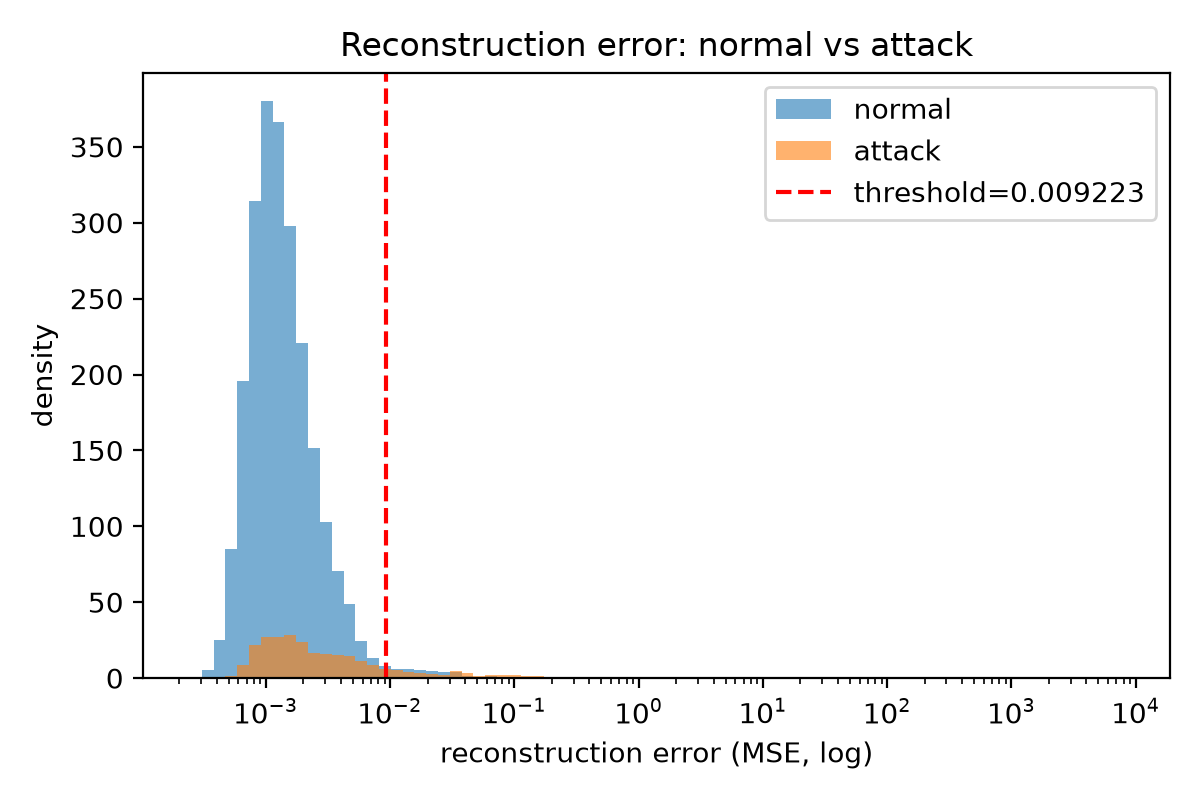

pr.png


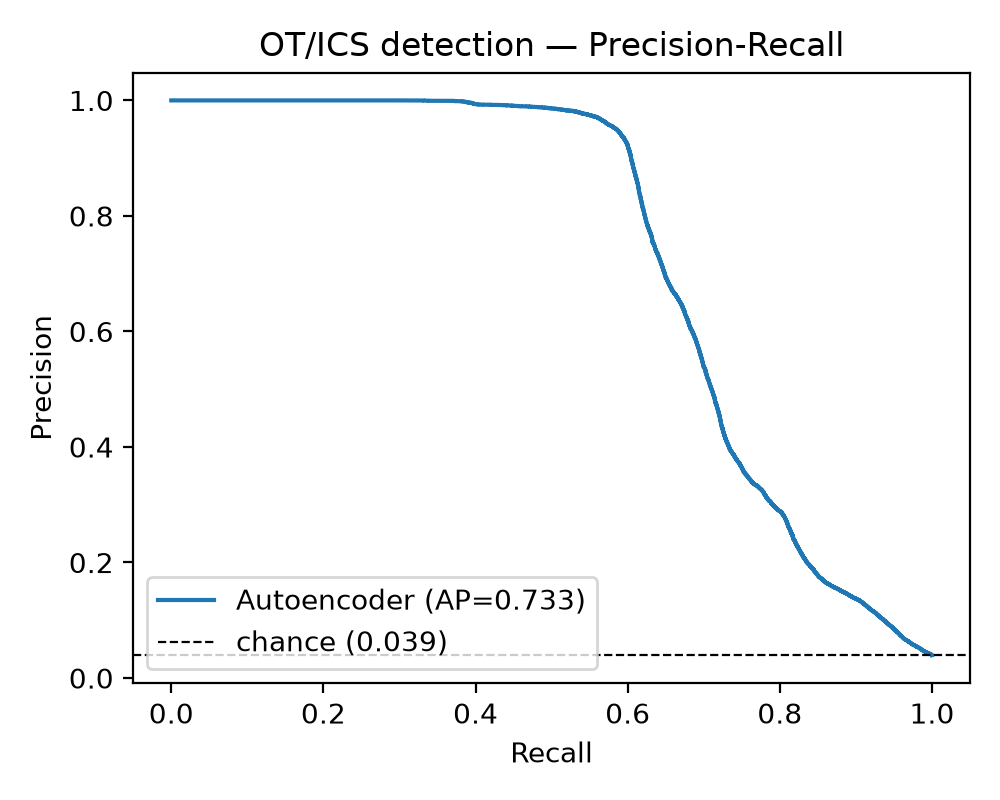

roc.png


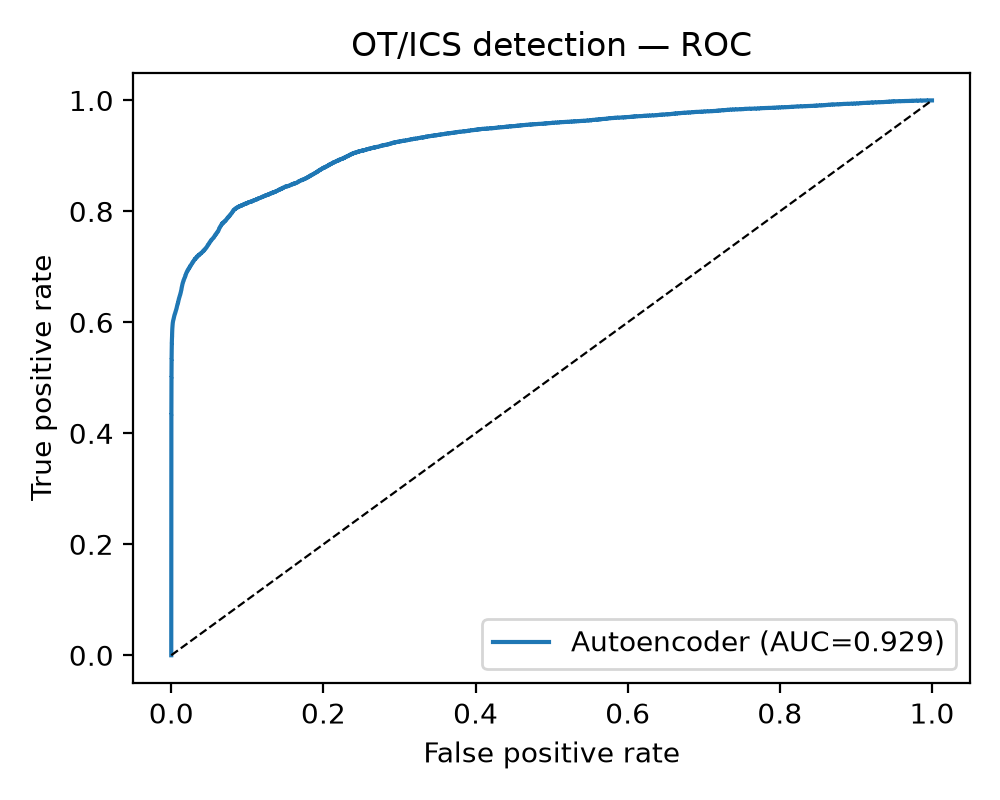

threshold_sweep.png


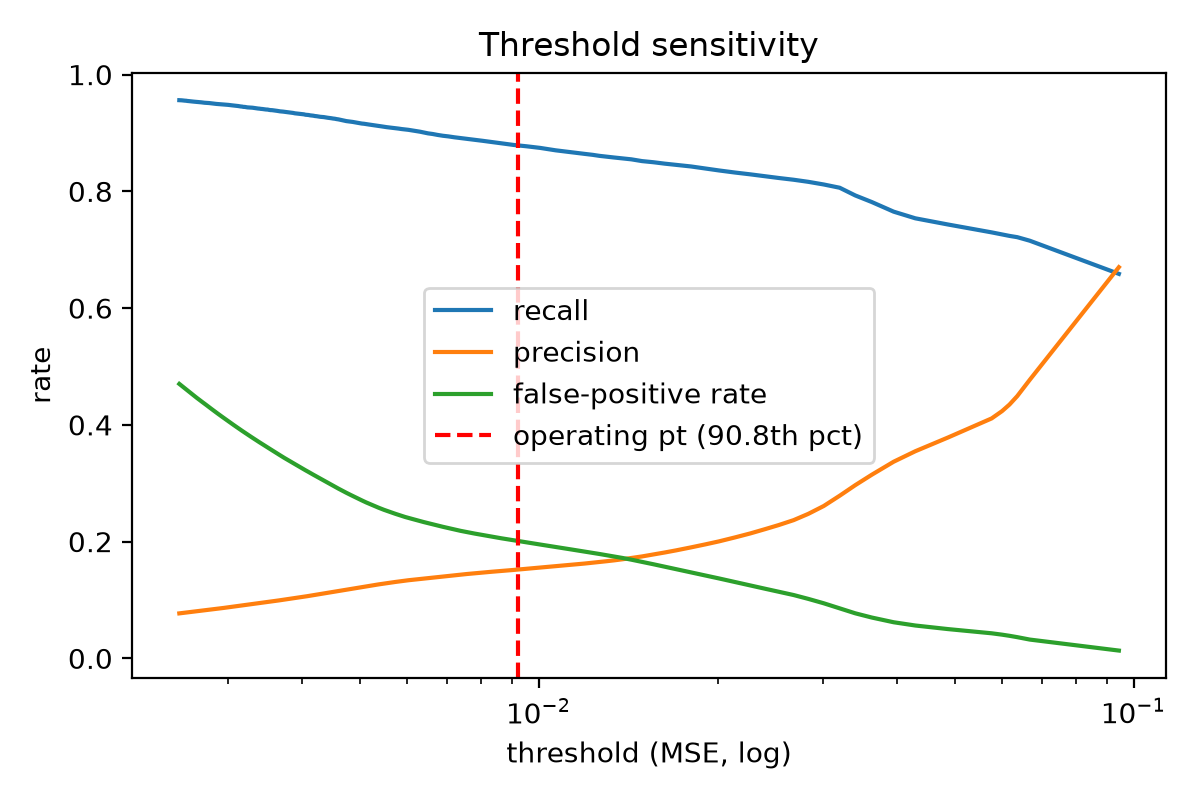

In [3]:
# --- display the result figures inline ---
import os
from IPython.display import Image, display

_figdir = REPO / "paper" / "ot_ics" / "figures"
for _f in sorted(os.listdir(_figdir)):
    if _f.endswith(".png") and not _f.startswith("eq_"):
        print(_f)
        display(Image(str(_figdir / _f)))
